## Transformer Sentence Classification

## 1. Data Preparation: Load and preprocess the data,
## ensuring the model can effectively process it.
#### This includes tokenization, handling of special tokens, and batch preparation.
#### Dataset: Pubmed 20k RCT dataset: https://github.com/lucianoscarpaci/datam-mach-learn

In [ ]:
!git clone https://github.com/lucianoscarpaci/datam-mach-learn/
!ls datam-mach-learn/PubMed_20k_RCT_dataset

Cloning into 'datam-mach-learn'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 2), reused 18 (delta 1), pack-reused 0
Receiving objects: 100% (19/19), 32.93 MiB | 7.84 MiB/s, done.
Resolving deltas: 100% (2/2), done.
dev.txt  test.txt  train.txt


In [ ]:
import os
work_dir = "datam-mach-learn/PubMed_20k_RCT_dataset/"
file_names = [work_dir + filename for filename in os.listdir(work_dir)]
file_names

['datam-mach-learn/PubMed_20k_RCT_dataset/train.txt',
 'datam-mach-learn/PubMed_20k_RCT_dataset/test.txt',
 'datam-mach-learn/PubMed_20k_RCT_dataset/dev.txt']

In [ ]:
import logging

def preprocess_text_with_line_numbers(filename):
    def read_lines(filepath):
        # Debug: Check if the file can be opened
        try:
            with open(filepath, 'r') as file:
                lines = file.readlines()
                logging.debug(f"Successfully read {len(lines)} lines from {filepath}")
                return lines
        except Exception as e:
            logging.error(f"Error reading {filepath}: {e}")
            return []

    # Debug: Indicate function start
    logging.debug(f"Starting to preprocess file: {filename}")

    input_lines = read_lines(filename)  # get all lines in the file
    logging.debug(f"Initial input lines: {input_lines[:5]}")  # Debug: Log the first few lines

    abstract_lines = ""  # create an empty list to store the data
    abstract_samples = []  # line data goes into samples

    # Loop through the lines in the file
    for line_idx, line in enumerate(input_lines):
        logging.debug(f"Processing line {line_idx}: {line.strip()}")  # Debug: Log current line

        if line.startswith("###"):  # check the tags in the line
            abstract_id = line.strip()
            logging.debug(f"Found abstract ID: {abstract_id}")  # Debug: Log abstract ID
            abstract_lines = ""  # reset abstract string

        elif line.isspace():  # check to see if line has a space
            logging.debug(f"Found empty line at index {line_idx}, processing abstract lines.")  # Debug: Empty line found

            abstract_line_split = abstract_lines.splitlines()  # split the lines
            logging.debug(f"Abstract lines: {abstract_line_split}")  # Debug: Log abstract lines

            # Iterate through each line and count the abstract lines
            for abstract_line_number, abstract_line in enumerate(abstract_line_split):
                logging.debug(f"Processing abstract line {abstract_line_number}: {abstract_line}")  # Debug: Log abstract line

                line_data = {}  # create a store of line data for which the labels will be seperated
                target_text_split = abstract_line.split("\t")  # split target label from text

                if len(target_text_split) == 2:
                    line_data["target"] = target_text_split[0]
                    line_data["text"] = target_text_split[1].lower()  # lower the text, makes it easier
                    line_data["line_number"] = abstract_line_number
                    line_data["total_lines"] = len(abstract_line_split) - 1

                    abstract_samples.append(line_data)  # add line data to abstract samples list
                    logging.debug(f"Added line data: {line_data}")  # Debug: Log line data
                else:
                    logging.warning(f"Skipping line {abstract_line_number} due to split issue: {abstract_line}")  # Debug: Skipping line

        else:  # if the line does not have the pattern of matched samples, strip the line
            abstract_lines += line
            logging.debug(f"Appending line to abstract_lines: {line.strip()}")  # Debug: Log appended line

    # Debug: Summary of results
    logging.info(f"Total number of processed abstracts: {len(abstract_samples)}")
    return abstract_samples

logging.basicConfig(level=logging.WARNING)
#logging.getLogger().setLevel(logging.DEBUG)

In [ ]:
%%time
train_samples = preprocess_text_with_line_numbers(work_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(work_dir + "dev.txt")
test_samples = preprocess_text_with_line_numbers(work_dir + "test.txt")
len(train_samples), len(val_samples), len(test_samples)

CPU times: user 3.25 s, sys: 188 ms, total: 3.44 s
Wall time: 3.45 s


(180040, 30212, 30135)

In [ ]:
# check if the train samples have been processed correctly
train_samples[:5]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [ ]:
# use pandas to create dataframe
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(5)
#val_df.head(5)
#test_df.head(5)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


## Verify the abstract sentences are correctly processed by showing sentences in the data

In [ ]:
# Use train, val, and test pandas dataframe and convert it to a list
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
# print the length of the train, val, and test
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

## Encode the labels to one-hot encoding for the transformer model

In [ ]:
from sklearn.preprocessing import OneHotEncoder


one_hot = OneHotEncoder(sparse_output=False)
train_labels = one_hot.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels = one_hot.fit_transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels = one_hot.fit_transform(test_df["target"].to_numpy().reshape(-1, 1))
train_labels
#val_labels
#test_labels

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Get the classes from the encoder to ensure the classes are correct
#### This is useful for programming the transformer model because we know 5 classes

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoded_train = encoder.fit_transform(train_df["target"].to_numpy().ravel())
encoded_val = encoder.fit_transform(val_df["target"].to_numpy().ravel())
encoded_test = encoder.fit_transform(test_df["target"].to_numpy().ravel())
class_count = len(encoder.classes_)
display_classes = encoder.classes_
class_count, display_classes

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Preparing the sentences for the transformer model
### plotting and visualization of tokens

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

The token length of each sentence: 26.338269273494777
The 95% length of each sentence (value in tokens): 55


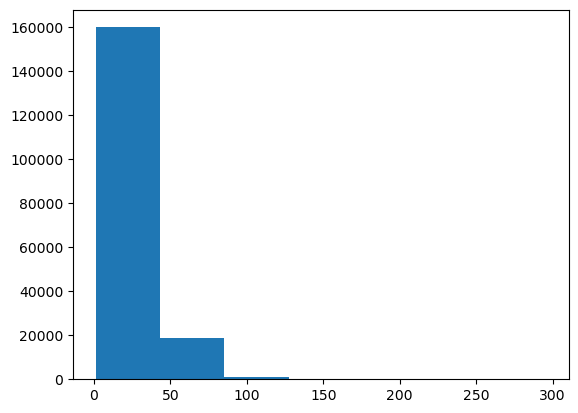

In [ ]:
# find the length of how long every sentence is
# in the token format
len_sentence = [len(sentence.split()) for sentence in train_sentences]
calc_avg_len_sentence = np.mean(len_sentence)
print(f"The token length of each sentence: {calc_avg_len_sentence}")
plt.hist(len_sentence, bins=7);
print(f"The 95% length of each sentence (value in tokens): {int(np.percentile(len_sentence, 95))}")

## To process the sentences into numbers for the model, 1) i will demostrate the use of TextVectorization from Tensorflow, and 2) create the text embeddings from Layers for the model to use that will be updated later.

In [ ]:
from tensorflow.keras.layers import TextVectorization, Embedding
import random

In [ ]:
# Function that processes the sentences from the original sentence to a vectorized sentence
def process_sentence_data(max_tokens=69000, output_sequence_length=55, target=random.choice(train_sentences)):
    # Initialize the sentence vectorizer
    sentence_vectorizer = TextVectorization(max_tokens=max_tokens,
                                            output_sequence_length=output_sequence_length)

    sentence_vectorizer.adapt(train_sentences)
    # Print the original sentence
    print(f"\nOriginal sentence:\n{target}")
    vectorized_sentence = sentence_vectorizer([target])
    # Print the vectorized sentence
    print(f"\nVectorized sentence:\n{vectorized_sentence}")
# Function that processes the vocabulary info from the sentence vectorizer
def process_vocabulary_info():
    # Initialize the sentence vectorizer
    sentence_vectorizer = TextVectorization(max_tokens=69000,
                                            output_sequence_length=55)

    sentence_vectorizer.adapt(train_sentences)
    rct_20k_vocab = sentence_vectorizer.get_vocabulary()
    total_words = len(rct_20k_vocab)
    # Print the number of words in the vocabulary
    print(f"Number of words in vocabulary: {total_words}")
    # Print the top 10 words in the vocabulary
    print(f"Top 10 words in vocabulary: {rct_20k_vocab[:10]}")

process_sentence_data()
process_vocabulary_info()


Original sentence:
the cset intervention was based on principles of exercise therapy for treatment of nonspecific low back pain .

Vectorized sentence:
[[    2 31901    38    10   261    18  4414     4   177    66    11    19
      4  3596   220  1051    65     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]
Number of words in vocabulary: 64841
Top 10 words in vocabulary: ['', '[UNK]', 'the', 'and', 'of', 'in', 'to', 'with', 'a', 'were']


In [ ]:
# Choose a random target sentence
target = random.choice(train_sentences)
# Initialize and adapt the TextVectorization layer
sentence_vectorizer = TextVectorization(max_tokens=69000, output_sequence_length=55)
sentence_vectorizer.adapt(train_sentences)
# Extract the vocabulary and get the total number of words
rct_20k_vocab = sentence_vectorizer.get_vocabulary()
total_words = len(rct_20k_vocab)
# Vectorize the target sentence
vectorized_sentence = sentence_vectorizer([target])
# Create the token embedding layer
token_embed = Embedding(input_dim=total_words, output_dim=128, mask_zero=True, name="token_embedding")
# DEBUG: print before and after sentence vectorization
print(f"Sentence before vectorization:\n{target}\n")
print(f"Sentence after vectorization (before embedding):\n{vectorized_sentence.numpy()}\n")
# Apply the embedding layer to the vectorized sentence
embedded_sentence = token_embed(vectorized_sentence)
# Print the embedded sentence and its shape
print(f"Sentence after embedding:\n{embedded_sentence.numpy()}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")

Sentence before vectorization:
the model predicted that this level of effectiveness was not reached until @ and @ days for gs-@ and sofosbuvir , respectively , and likely represents the time needed to accumulate intracellular triphosphates .

Sentence after vectorization (before embedding):
[[    2   314   830    28    23   204     4   257    10    31  1436   634
      3    84    11  4780     3  6146    83     3   532  2892     2    63
    440     6 21276  8047 43219     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]

Sentence after embedding:
[[[ 0.04923983  0.04992131  0.00808555 ...  0.00376987 -0.03691369
    0.0099413 ]
  [-0.04139895  0.04859222 -0.03064235 ... -0.01610308  0.02546236
    0.04798026]
  [ 0.03551118 -0.04584265  0.04996749 ...  0.01823789  0.03846903
   -0.0486996 ]
  ...
  [-0.01285472 -0.02554079  0.02965425 ... -0.00294767  0.01106826
    0.03210844]
 

# Fine-tune and convert the sentences into tensorflow datasets for the model

In [ ]:
# Convert the sentences into Tensorflow
# Convert train data to tf.data.Dataset
tf_train = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels))
tf_train = tf_train.shuffle(buffer_size=len(train_sentences)).batch(2).prefetch(tf.data.AUTOTUNE)
# Convert valid data to tf.data.Dataset
tf_valid = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels))
tf_valid = tf_valid.batch(2).prefetch(tf.data.AUTOTUNE)
# Convert test data to tf.data.Dataset
tf_test = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels))
tf_test = tf_test.batch(2).prefetch(tf.data.AUTOTUNE)

## 2. Model Implementation:
    Implement a Transformer model for sentence classification. You may use pre-existing models like BERT, GPT, or develop your own variant.
    Fine-tune the model on the dataset, ensuring it is appropriately adjusted to the task of classifying sentences in biomedical abstracts.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import TextVectorization, Embedding, LayerNormalization, MultiHeadAttention, Dense, Dropout, GlobalAveragePooling1D

In [ ]:
# define variables for the Transformer model
max_tokens=69000
output_sequence_length=55
head_size = 128
num_heads = 4
ff_dim = 128
num_transformer_blocks = 4
mlp_units = 128
dropout = 0.1
mlp_dropout = 0.1
num_classes = 5  # Number of output classes

In [ ]:
# Initialize and adapt the TextVectorization layer
sentence_vectorizer = TextVectorization(max_tokens=max_tokens, output_sequence_length=output_sequence_length)
sentence_vectorizer.adapt(train_sentences)
# Extract the vocabulary and get the total number of words
rct_20k_vocab = sentence_vectorizer.get_vocabulary()
total_words = len(rct_20k_vocab)
# Create the token embedding layer
token_embed = Embedding(input_dim=total_words, output_dim=128, mask_zero=True, name="token_embedding")
# Define the Transformer Encoder function
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return x + res
# Build the Transformer model using token embeddings
def build_transformer_model(head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0, num_classes=5):
    # Input shape of 1D vector, each input will have one feature
    inputs = layers.Input(shape=(1,), dtype=tf.string)
    # sentence vectorizer, sentence -> vector
    sentence_vectors = sentence_vectorizer(inputs)
    # create the token embeddings, vector -> tokenize
    token_embeddings = token_embed(sentence_vectors)
    # define the input from the token embeddings
    x = token_embeddings
    for _ in range(num_transformer_blocks):
        # encapsulates a single transformer encoder layer
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    # Apply layer normalization to stablize the training
    # epsilon 1e-6 to prevent division by zero
    x = LayerNormalization(epsilon=1e-6)(x)
    # reduce dimensionality from 3d to 2d
    x = GlobalAveragePooling1D()(x)
    # two fully connected dense layers with relu activation function
    x = Dense(mlp_units, activation="relu")(x)
    # drop out layer val = 0.1 applied to prevent model overfitting
    x = Dropout(mlp_dropout)(x)
    x = Dense(mlp_units, activation="relu")(x)
    # drop out layer val = 0.1 applied to prevent model overfitting
    x = Dropout(mlp_dropout)(x)
    # last dense layer with softmax activation function
    outputs = Dense(num_classes, activation="softmax")(x)
    # combines inputs and outputs to create a model
    return Model(inputs, outputs)

In [ ]:
# Build and compile the Transformer model
model_alt = build_transformer_model(head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout, mlp_dropout, num_classes)
model_alt.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=["accuracy"])

In [ ]:
# Begin the Transformer model training with 'history'
# Train the model
history = model_alt.fit(
    tf_train,
    steps_per_epoch=int(0.1 * len(tf_train)),
    epochs=10,
    validation_data=tf_valid,
    validation_steps=int(0.1 * len(tf_valid))
)

Epoch 1/10


/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:877: UserWarning: Layer 'query' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:877: UserWarning: Layer 'key' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:877: UserWarning: Layer 'value' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1707s 187ms/step - accuracy: 0.4745 - loss: 1.2427 - val_accuracy: 0.6444 - val_loss: 0.9186
Epoch 2/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1684s 187ms/step - accuracy: 0.6196 - loss: 0.9709 - val_accuracy: 0.6252 - val_loss: 0.9163
Epoch 3/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1735s 193ms/step - accuracy: 0.6394 - loss: 0.9379 - val_accuracy: 0.6685 - val_loss: 0.8536
Epoch 4/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1699s 189ms/step - accuracy: 0.6639 - loss: 0.8758 - val_accuracy: 0.6775 - val_loss: 0.8267
Epoch 5/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1714s 190ms/step - accuracy: 0.6661 - loss: 0.8763 - val_accuracy: 0.6626 - val_loss: 0.8455
Epoch 6/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1712s 190ms/step - accuracy: 0.6779 - loss: 0.8378 - val_accuracy: 0.7149 - val_loss: 0.7743
Epoch 7/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1786s 198ms/step - accuracy: 0.6661 - loss: 0.8491 - val_accuracy: 0.6954 - val_loss: 0.8084
Epoch 8/10
9002/9002 ━━━━━━━━━━━━━━━━━━━━ 1840s 204ms/step - accur

## 3. Evaluation:
    Evaluate the model using appropriate metrics such as accuracy, F1 score, and confusion matrix.
    Analyze the model's performance, highlighting its strengths and weaknesses in different classification categories.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
#Evaluation on the model
# array of predicted probabilities for each class
val_pred = model_alt.predict(tf_valid)
# Gets the predicted classes, array of class labels
val_classes_pred = tf.argmax(val_pred, axis=1)
# use the true labels one-hot encoded val_labels for valid set
val_true_classes = tf.argmax(val_labels, axis=1)
#Calculate the validation accuracy and the f1 score
acc = accuracy_score(val_true_classes, val_classes_pred)
f1 = f1_score(val_true_classes, val_classes_pred, average='weighted')
#Print the accuracy and the f1 score
print(f'Validation Accuracy: {acc}')
print(f'Validation f1 Score: {f1}')

15106/15106 ━━━━━━━━━━━━━━━━━━━━ 459s 30ms/step
Validation Accuracy: 0.6889646498080233
Validation f1 Score: 0.6655715382048474


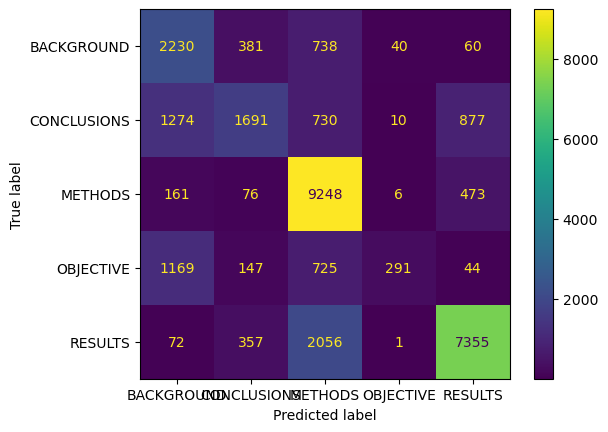

In [ ]:
#Generate the confusion matrix
# arguments the true val classes, and the predicted classes
confus_matrix = confusion_matrix(val_true_classes, val_classes_pred)
# create a display of the confusion matrix
target_names = encoder.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=confus_matrix, display_labels=target_names)
#Plot the confusion matrix with the hot colormap
disp.plot(cmap=plt.cm.viridis)
# Show the plot with results
plt.show()

## Summary of Metrics

In [ ]:
#Plotting metrics obtained by the confusion matrix plot above
target_names = encoder.classes_
print(classification_report(val_true_classes, val_classes_pred, target_names=target_names, digits=3))

              precision    recall  f1-score   support

  BACKGROUND      0.455     0.647     0.534      3449
 CONCLUSIONS      0.638     0.369     0.468      4582
     METHODS      0.685     0.928     0.788      9964
   OBJECTIVE      0.836     0.122     0.214      2376
     RESULTS      0.835     0.747     0.789      9841

    accuracy                          0.689     30212
   macro avg      0.690     0.563     0.558     30212
weighted avg      0.712     0.689     0.666     30212



## Analysis
>The model has the best precision and f1 score in the 'METHODS' and 'RESULTS' classes. This is proof that the model can identifying sentences because most of the sentences are in these classes.
>The model has the worst precision and f1 score in the 'BACKGROUND' and 'OBJECTIVE' class. This is indicating there is a high amount of misclassification in these categories.

## 4. Discussion:
    Discuss how the Transformer architecture benefits the task of sequential sentence classification.
    Compare its performance against a baseline model, such as a simple RNN or LSTM.

>In this research, the transformer architecture was beneficial to process sentences that were embedded and tokenized. In the cells above before running the model i explained and demonstrated sentences before vectorization, vectorization of sentences, embedding, the length of tokens in a sentence etc. The transformer is beneficial to use for tokenized sentences because the architecture is built for parallel processing which has better performance and use-case for PubMed RCT-20k Dataset. Compared to RNN or LSTM which are designed to be sequential, it would be lower performing for sentence classification because they would have slower training times and lower metric scores than Transformer.

## Encoding sentence information in LSTMs vs. Transformers

>LSTMs process input sentence token by token, controlled by a hidden state that is updated based on the current input and previous hidden state. LSTMs maintain the order of tokens that are processed.
>While using one-hot encoded labels as input, each token is binary, the order of this dramatically affects how the sentences are processed.
>Transformers process the entire input (many sentences) by using a mechanism called 'self-attention' to make relationships between a token and the tokens in the input. Transformers can use tokens no matter what position inside the input.
>Transformers use positional encoding, it cannot encode the tokens sequentially, then the positional encodings are added to the token embeddings.